In [1]:
!nvidia-smi

Unable to determine the device handle for GPU0000:01:00.0: Unknown Error


In [2]:
import os

os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"
os.environ["HF_HUB_ETAG_TIMEOUT"] = "60"
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "600"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("HF_ENDPOINT:", os.environ.get("HF_ENDPOINT"))
print("HF_HUB_DISABLE_XET:", os.environ.get("HF_HUB_DISABLE_XET"))

HF_ENDPOINT: https://hf-mirror.com
HF_HUB_DISABLE_XET: 1


In [3]:
MODEL_NAME   = "bert-base-uncased"
DATA_DIR     = "/home/yangdejin/nlpcc/nlpcc_task2/data"
OUTPUT_DIR   = "/home/yangdejin/nlpcc/nlpcc_task2/outputs/encoder/bert_rdrop"
LOGGING_DIR = "/home/yangdejin/nlpcc/nlpcc_task2/logs/bert_rdrop"

NUM_EPOCHS = 5
TRAIN_BATCH_SIZE = 4
EVAL_BATCH_SIZE = 8
WARMUP_STEPS = 500
WEIGHT_DECAY = 0.01
LOGGING_STEPS = 100
SEED = 3407

TRAIN_CONTEXT_MODE = "full_context"
EVAL_CONTEXT_MODE = "response_only"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOGGING_DIR, exist_ok=True)
print(f"Model : {MODEL_NAME}")
print(f"Data  : {DATA_DIR}")
print(f"Output: {OUTPUT_DIR}")

Model : bert-base-uncased
Data  : /home/yangdejin/nlpcc/nlpcc_task2/data
Output: /home/yangdejin/nlpcc/nlpcc_task2/outputs/encoder/bert_rdrop


In [4]:
# Cell 3: 标签定义 + 类别分布统计
import json
from collections import Counter

VALUE_LABELS = [
    "Self-direction–thought",
    "Self-direction–action",
    "Stimulation",
    "Hedonism",
    "Achievement",
    "Power–dominance",
    "Power–resources",
    "Face",
    "Security–personal",
    "Security–societal",
    "Tradition",
    "Conformity–rules",
    "Conformity–interpersonal",
    "Humility",
    "Benevolence–dependability",
    "Benevolence–caring",
    "Universalism–concern",
    "Universalism–nature",
    "Universalism–tolerance",
]

NUM_CLASSES = len(VALUE_LABELS)
label2id = {v: i for i, v in enumerate(VALUE_LABELS)}
id2label = {i: v for i, v in enumerate(VALUE_LABELS)}

print(f"Number of classes: {NUM_CLASSES}")

train_vals = []
with open(os.path.join(DATA_DIR, "train.jsonl")) as f:
    for line in f:
        train_vals.append(json.loads(line)["Value"])

counter = Counter(train_vals)
print("\nTrain class distribution:")
for label in VALUE_LABELS:
    print(f"  {label:<40s}: {counter[label]}")

Number of classes: 19

Train class distribution:
  Self-direction–thought                  : 119
  Self-direction–action                   : 124
  Stimulation                             : 400
  Hedonism                                : 164
  Achievement                             : 174
  Power–dominance                         : 156
  Power–resources                         : 237
  Face                                    : 258
  Security–personal                       : 202
  Security–societal                       : 70
  Tradition                               : 90
  Conformity–rules                        : 385
  Conformity–interpersonal                : 236
  Humility                                : 100
  Benevolence–dependability               : 189
  Benevolence–caring                      : 317
  Universalism–concern                    : 160
  Universalism–nature                     : 71
  Universalism–tolerance                  : 68


In [5]:
# Cell 4: 数据加载 + 文本拼接
import json
import torch
import numpy as np
from datasets import Dataset

def build_text(row, context_mode="full_context"):
    response = str(row.get("Consistent Value Response", "")).strip()
    if context_mode == "response_only":
        return "Response: " + response
    if context_mode == "full_context":
        parts = []
        if row.get("Scenario"):
            parts.append("Senario: " + str(row.get("Senario")).strip())
        if row.get("Question"):
            parts.append("Question: " + str(row.get("Question")).strip())
        if response:
            parts.append("Response: " + response)
        return " [SEP] ".join(parts)
    
def load_jsonl(path, has_label=True, context_mode = "full_context"):

    texts, labels = [], []
    with open(path) as f:
        for line in f:
            row = json.loads(line)
            texts.append(build_text(row, context_mode))
            if has_label:
                labels.append(label2id[row["Value"]])
    if has_label:
        return Dataset.from_dict({"text": texts, "label": labels})
    return Dataset.from_dict({"text": texts})

train_dataset = load_jsonl(os.path.join(DATA_DIR, "train.jsonl"), context_mode=EVAL_CONTEXT_MODE)
dev_dataset   = load_jsonl(os.path.join(DATA_DIR, "dev.jsonl"), context_mode=EVAL_CONTEXT_MODE)

print(f"Train size : {len(train_dataset)}")
print(f"Dev size   : {len(dev_dataset)}")
print(f"\nTrain sample text:\n{train_dataset[0]['text'][:300]}")
print(f"\nDev sample text:\n{dev_dataset[0]['text'][:300]}")

Train size : 3520
Dev size   : 514

Train sample text:
Response: I would suggest alternative solutions diplomatically, ensuring my input is heard without challenging the manager openly, prioritizing team harmony and respect for hierarchy.

Dev sample text:
Response: I would prioritize maintaining that frequent contact despite my schedule, as I want to ensure my teammate feels valued, included, and that our teamwork remains perfectly smooth.


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import BertTokenizerFast, DataCollatorWithPadding
from transformers import BertPreTrainedModel, BertModel
from transformers.modeling_outputs import SequenceClassifierOutput

class BertScratch(BertPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.config = config
        self.bert = BertModel(config)
        classifier_dropout = (
            config.classifier_dropout if config.classifier_dropout is not None else config.hidden_dropout_prob
        )
        self.dropout = nn.Dropout(classifier_dropout)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)
        self.post_init()
    def forward(self, input_ids=None, attention_mask=None, token_type_ids = None, labels=None):
        outputs = self.bert(input_ids, attention_mask, token_type_ids)
        pooled_output = outputs[1]
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        kl_outputs = self.bert(input_ids, attention_mask, token_type_ids)
        kl_pooled_output = kl_outputs[1]
        kl_pooled_output = self.dropout(kl_pooled_output)
        kl_logits = self.classifier(kl_pooled_output)

        total_loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))
            ce_loss = loss_fct(kl_logits.view(-1, self.num_labels), labels.view(-1))
            kl_loss = (KL(logits, kl_logits, "sum") + KL(kl_logits, logits, "sum")) / 2.0
            total_loss = loss + ce_loss + kl_loss
        
        return SequenceClassifierOutput(
            loss = total_loss,
            logits = logits,
            hidden_states = outputs.hidden_states,
            attentions = outputs.attentions,
        )
def KL(input, target, reduction="sum"):
    input = input.float()
    target = target.float()
    loss = F.kl_div(
        F.log_softmax(input, dim = -1, dtype=torch.float32),
        F.softmax(target, dim = -1, dtype=torch.float32),
        reduction = reduction,
    )
    return loss
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenizer_fn(examples):
    return tokenizer(examples["text"], truncation = True)

train_dataset = train_dataset.map(tokenizer_fn, batched=True)
dev_dataset = dev_dataset.map(tokenizer_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer = tokenizer)
model = BertScratch.from_pretrained(MODEL_NAME, num_labels = NUM_CLASSES)
model.config.id2label = id2label
model.config.label2id = label2id

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


Map:   0%|          | 0/3520 [00:00<?, ? examples/s]

Map:   0%|          | 0/514 [00:00<?, ? examples/s]

Some weights of BertScratch were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters: 109496851


In [7]:
# Cell 6: 模型参数统计
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,} ({100 * trainable / total:.2f}%)")

Trainable parameters: 109,496,851 / 109,496,851 (100.00%)


In [8]:
# Cell 7: 训练
import inspect
import evaluate
import numpy as np
from transformers import TrainingArguments, Trainer

accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1  = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "macro_f1": f1}

training_kwargs = dict(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    warmup_steps=WARMUP_STEPS,
    weight_decay=WEIGHT_DECAY,
    logging_dir=LOGGING_DIR,
    logging_steps=LOGGING_STEPS,
    save_strategy="no",
    seed=SEED,
    report_to="none",
)
if "eval_strategy" in inspect.signature(TrainingArguments.__init__).parameters:
    training_kwargs["eval_strategy"] = "epoch"
else:
    training_kwargs["evaluation_strategy"] = "epoch"

training_args = TrainingArguments(**training_kwargs)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer_stats = trainer.train()
print(trainer_stats)

/tmp/ipykernel_2098321/1169971219.py:37: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.207100,1.034176,0.852140,0.816688
2,0.748200,0.869102,0.912451,0.903118
3,0.373200,0.938203,0.920233,0.902795
4,0.199700,1.044751,0.912451,0.899929
5,0.065300,0.979212,0.928016,0.912982


TrainOutput(global_step=4400, training_loss=0.7617205653492023, metrics={'train_runtime': 194.7667, 'train_samples_per_second': 90.365, 'train_steps_per_second': 22.591, 'total_flos': 356812489686576.0, 'train_loss': 0.7617205653492023, 'epoch': 5.0})


Dev Set Evaluation Results — R-Drop
                           precision    recall  f1-score   support

   Self-direction–thought     0.8750    0.8235    0.8485        17
    Self-direction–action     0.8889    0.8889    0.8889        18
              Stimulation     0.9831    1.0000    0.9915        58
                 Hedonism     0.9600    1.0000    0.9796        24
              Achievement     0.9600    0.9231    0.9412        26
          Power–dominance     0.9565    0.9565    0.9565        23
          Power–resources     1.0000    0.9714    0.9855        35
                     Face     0.9189    0.9189    0.9189        37
        Security–personal     1.0000    0.8966    0.9455        29
        Security–societal     0.9091    0.9091    0.9091        11
                Tradition     0.9333    1.0000    0.9655        14
         Conformity–rules     0.9474    0.9818    0.9643        55
 Conformity–interpersonal     0.8205    0.9412    0.8767        34
                 Humility

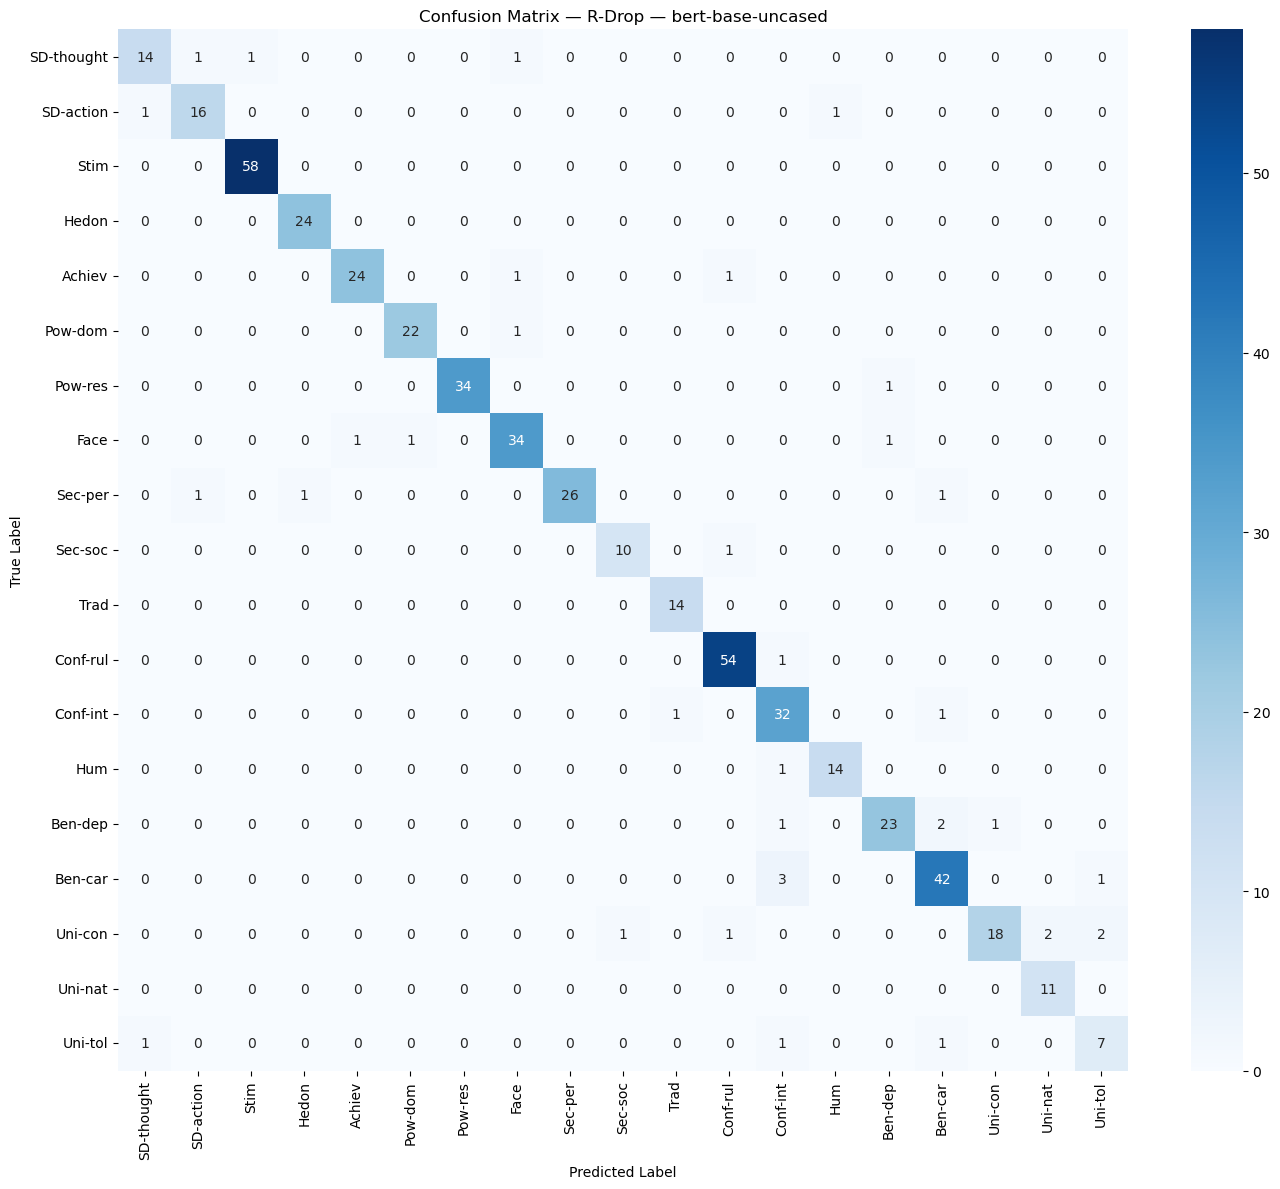

Confusion matrix saved to /home/yangdejin/nlpcc/nlpcc_task2/outputs/encoder/bert_rdrop/confusion_matrix.png


In [10]:
# Cell 8: Dev 集综合评估 + 每类 F1 + 混淆矩阵热图
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

pred_output = trainer.predict(dev_dataset)
preds  = np.argmax(pred_output.predictions, axis=-1)
labels = np.array(dev_dataset["label"])

print("=" * 60)
print("Dev Set Evaluation Results — R-Drop")
print("=" * 60)
print(classification_report(
    labels, preds,
    target_names=VALUE_LABELS,
    digits=4
))

cm = confusion_matrix(labels, preds)
short_labels = [
    "SD-thought", "SD-action", "Stim", "Hedon", "Achiev",
    "Pow-dom", "Pow-res", "Face", "Sec-per", "Sec-soc",
    "Trad", "Conf-rul", "Conf-int", "Hum", "Ben-dep",
    "Ben-car", "Uni-con", "Uni-nat", "Uni-tol"
]

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=short_labels, yticklabels=short_labels
)
plt.title(f"Confusion Matrix — R-Drop — {MODEL_NAME}")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()
print(f"Confusion matrix saved to {OUTPUT_DIR}/confusion_matrix.png")